# Customer Churn Prediction — Technical Notebook

## 1. Import Libraries


In [38]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
from statsmodels.stats.proportion import proportion_confint, proportions_ztest
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from datetime import datetime , timedelta

## 2. Load Data


In [ ]:
# Load the raw dataset exported from the source system
df = pd.read_csv(r'F:\WORK\Orient Group\Sources\الكل 11-05-2026.csv')

## 3. Initial Exploration


In [3]:
df.describe()

,كود الفرع,InvoiceNo,عدد العملاء,عدد الفائزين,عدد الغير فائزين,عدد متأخر - غير فائز,قيمة المتأخرات - غير فائز,عدد متأخر - فائز,قيمة المتأخرات - فائز,عدد سحب غير فائز,...,قيمة السداد الفردي,عدد الربط - صافي,عدد الفردي - صافي,قيمة السداد الربط - صافي,قيمة السداد الفردي - صافي,كود العميل,كود العميل الرئيسي,عدد الأقساط,قيمة القسط,إجمالي قيمة السداد
count,20914.000000,20914.000000,20914.0,20914.000000,20914.000000,20914.000000,20914.000000,20914.000000,20914.000000,20914.000000,...,20914.000000,20914.000000,20914.000000,20914.000000,20914.000000,20914.000000,20913.000000,20913.000000,20913.000000,20914.000000
mean,14.595295,1116.335995,1.0,0.395907,0.531271,0.194033,1178.144018,0.150043,427.690303,0.124271,...,8643.287559,0.157932,0.058382,855.301234,364.035813,10810.687530,9925.898819,19.063597,1148.336441,9739.195969
std,5.777818,962.816541,0.0,0.489056,0.499033,0.395464,3808.778918,0.357122,1584.684021,0.329898,...,8636.329296,0.364686,0.234470,2870.998600,2037.192753,6153.620555,6867.860171,7.763706,519.610474,8368.395669
min,1.000000,1.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,11.000000,355.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1000.000000,0.000000,0.000000,0.000000,0.000000,5523.250000,2946.000000,23.000000,1000.000000,2000.000000
50%,14.000000,807.000000,1.0,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,6000.000000,0.000000,0.000000,0.000000,0.000000,10866.500000,10766.000000,23.000000,1000.000000,7500.000000
75%,16.000000,1689.000000,1.0,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,15000.000000,0.000000,0.000000,0.000000,0.000000,16127.750000,16005.000000,23.000000,1500.000000,16000.000000
max,28.000000,4035.000000,1.0,1.000000,1.000000,1.000000,160000.000000,1.000000,27000.000000,1.000000,...,60000.000000,1.000000,1.000000,25500.000000,48000.000000,21394.000000,21394.000000,23.000000,20000.000000,60000.000000


In [5]:
print(df.dtypes)

كود الفرع                             int64
اسم الفرع                               str
مركز التكلفة                            str
InvoiceNo                             int64
DayDate                                 str
DeliveryDate                            str
DeliveryDate2                           str
تاريخ التسليم المبدئي - الفائزين        str
عدد العملاء                           int64
عدد الفائزين                          int64
عدد الغير فائزين                      int64
عدد متأخر - غير فائز                  int64
قيمة المتأخرات - غير فائز             int64
عدد متأخر - فائز                      int64
قيمة المتأخرات - فائز                 int64
عدد سحب غير فائز                      int64
قيمة سداد السحب غير فائز              int64
عدد سحب فائز                          int64
قيمة سداد السحب فائز                float64
نوع السحب                               str
عدد الصافي                            int64
قيمة السداد                           int64
عدد الربط                       

## 4. Data Cleaning & Feature Engineering


In [6]:
# Transforming data to the correct Data types
df = df.drop_duplicates()
df['DayDate'] = pd.to_datetime(df['DayDate'])
df['winning_date'] = pd.to_datetime(df['DeliveryDate'])
df['travel_date'] = pd.to_datetime(df['DeliveryDate2'])
df['DeliveryDate2'] = pd.to_datetime(df['DeliveryDate2'])
df['travel_status'] = df['DeliveryDate2'].apply(lambda x: "travelled" if x > pd.Timestamp('1900-01-01') else "not_travelled")
df['DeliveryDate'] = pd.to_datetime(df['DeliveryDate'])
df['winning_status'] = df['DeliveryDate'].apply(lambda x: "winner" if x > pd.Timestamp('1900-01-01') else "not_winner")
df['total_arears'] = df['قيمة المتأخرات - فائز'] + df['قيمة المتأخرات - غير فائز']
df['pay_status'] = df['عدد متأخر - غير فائز'] + df['عدد متأخر - فائز']
df['customer_status'] = df['عدد سحب غير فائز'] + df['عدد سحب فائز']
df['refund_amount'] = df['قيمة سداد السحب غير فائز'] + df['قيمة سداد السحب فائز']

In [20]:
# drop unnecessery Columns
df_clean = df[['اسم الفرع', 'DayDate',
       'عدد الربط', 'عدد الفردي', 'عدد الربط - صافي', 'عدد الفردي - صافي',
       'قيمة السداد الفردي - صافي','كود العميل','اسم العميل','عدد الأقساط',
      'total_arears', 'pay_status', 'customer_status', 'refund_amount',
       'winning_date', 'travel_date','winning_status', 'travel_status']]



In [21]:
df_clean['customer_status'] = df_clean['customer_status'].apply(lambda x: "active" if x == 1 else "lost")
df_clean['pay_status'] = df_clean['pay_status'].apply(lambda x: "delay" if x == 1 else "committed")
df_clean['customer_type'] = df_clean['عدد الفردي'].apply(lambda x: "sinle" if x == 1 else "group")
df_clean.drop(columns= 'قيمة السداد الفردي - صافي',inplace=True)


In [22]:
df_clean['branch_name'] = df_clean['اسم الفرع']
df_clean['customer_name'] = df_clean['اسم العميل']
df_clean['customer_code'] = df_clean['كود العميل']
df_clean['instal_amount'] = df['قيمة القسط']
df_clean['instal_count'] = df_clean['عدد الأقساط']
df_clean['total_paid'] = df['إجمالي قيمة السداد']

In [23]:
df_clean.drop(columns= ['اسم الفرع', 'كود العميل', 'اسم العميل', 'عدد الأقساط'],inplace=True)

In [ ]:
df_clean.sample(10)

In [25]:
df_clean.dtypes

DayDate              datetime64[us]
عدد الربط                     int64
عدد الفردي                    int64
عدد الربط - صافي              int64
عدد الفردي - صافي             int64
total_arears                  int64
pay_status                      str
customer_status                 str
refund_amount               float64
winning_date         datetime64[us]
travel_date          datetime64[us]
winning_status                  str
travel_status                   str
customer_type                   str
branch_name                     str
customer_name                   str
customer_code                 int64
instal_amount               float64
instal_count                float64
total_paid                  float64
dtype: object

In [ ]:
df_clean.head(5)

## 5. Select Relevant Columns


In [ ]:
df_regression = df_clean[['customer_code','customer_status', 'customer_type', 'instal_amount', 'instal_count', 'winning_status']]
df_regression


## 6. Encode Business Labels


In [41]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [64]:
## Encoding the categorical variables to all numeric for regression model
df_regression = df_regression.dropna()
df_regression['customer_status'] = le.fit_transform(df_regression['customer_status'])
df_regression['customer_type']   = le.fit_transform(df_regression['customer_type'])
df_regression['winning_status']  = le.fit_transform(df_regression['winning_status'])
X= df_regression.drop(columns=['customer_code','customer_status']).dropna()
Y= df_regression['customer_status'].dropna()


## 7. Train / Test Split


In [65]:
## seperate data to train and test sets train with 70% of data and test with 30% of data
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)


## 8. Train Logistic Regression Model


In [101]:
## Training the model to be able to predict the customer status based on the other features
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

## 9.Evaluate Logistic Model

In [143]:
precision = metrics.precision_score(y_test, model.predict(x_test))
print(f"Precision: {precision*100:.2f}%")

recall = metrics.recall_score(y_test, model.predict(x_test))
print(f"Recall: {recall *100:.2f}%")

f1 = metrics.f1_score(y_test, model.predict(x_test))
print(f"F1-Score: {f1 * 100:.2f}%")
from sklearn.metrics import roc_auc_score
print(f"AUC: {roc_auc_score(y_test, predicted_probabilities) * 100:.2f}%")

Precision: 97.47%
Recall: 99.96%
F1-Score: 98.70%
AUC: 96.96%


In [107]:
## Evaluating the model's performance using Precision, Recall, Accuracy
# Class 0 is customer active
# Class 1 is customer will be lost
from sklearn.metrics import classification_report
CLF = classification_report(y_test, model.predict(x_test))
print(CLF)

              precision    recall  f1-score   support

           0       1.00      0.90      0.94      1258
           1       0.97      1.00      0.99      5016

    accuracy                           0.98      6274
   macro avg       0.99      0.95      0.97      6274
weighted avg       0.98      0.98      0.98      6274



## 10.Confusion Matrix

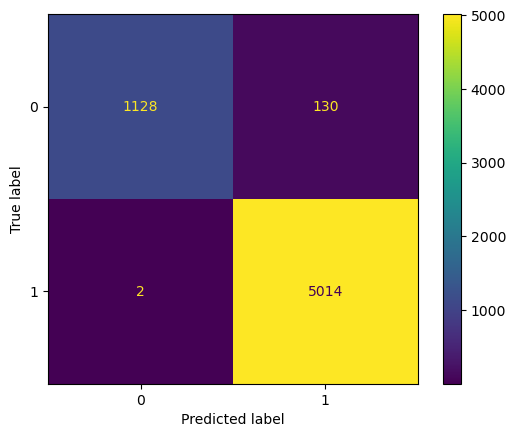

In [71]:
## graphical representation of the model's performance using confusion matrix  
import sklearn.metrics as metrics
cm = metrics.confusion_matrix(y_test, model.predict(x_test))
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
display.plot()

<Axes: ylabel='customer_status'>

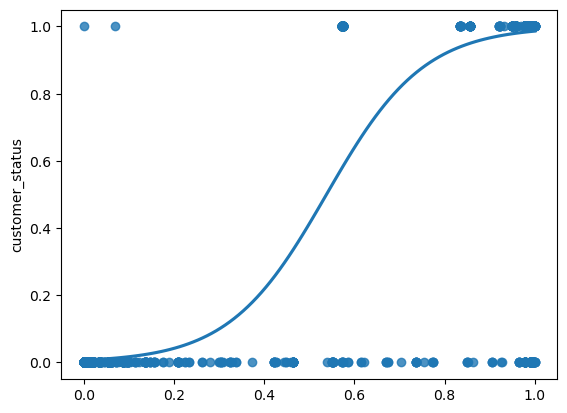

In [88]:
sns.regplot(x=predicted_probabilities, y=y_test, logistic=True, ci=None)

##  Churn Probability Scores


In [ ]:
# Adding the predicted probabilities to the original dataset and categorizing customers based on their churn probability
df_clean.loc[y_test.index, 'Churn Probability'] = predicted_probabilities * 100
df_clean['risk_level'] = pd.cut(df_clean['Churn Probability'], bins=[0, 20, 40, 60, 80, 100], labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
df_clean.sample(10)



In [ ]:
df_clean = df_clean[df_clean['Churn Probability'].notnull()]
df_clean.sample(10)

In [145]:
# Exporting Clean Data To Postgresql 
 
db_user = 'postgres'
db_password = 'Alahly1907'
db_host = 'localhost' 
db_port = '5432' 
db_name = 'orient'


engine_url = f'postgresql+psycopg2://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}'
engine = create_engine(engine_url)


table_name = 'Sales_analysis'
## "this line to make sure that the newly added data will be appended to the old existing Data"
try:
  
    df_clean.to_sql(table_name, engine, if_exists='append', index=False)
    print("Success: Data loaded to PostgreSQL successfully!")
except Exception as e:
    print(f"Error occurred: {e}")

Success: Data loaded to PostgreSQL successfully!
